In [4]:
import os
import random
import warnings

import numpy as np
import pandas as pd

from bertopic import BERTopic
from bertopic.representation import KeyBERTInspired
from umap import UMAP
from hdbscan import HDBSCAN
from sklearn.feature_extraction.text import CountVectorizer

import statsmodels.formula.api as smf

import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")


/opt/homebrew/Caskroom/miniforge/base/envs/datascience312/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
import pandas as pd
from collections import Counter
import os

def load_datasets(folder, prefix):
    l = pd.read_csv(f"{folder}/{prefix}_leftwing.csv")
    r = pd.read_csv(f"{folder}/{prefix}_rightwing.csv")
    n = pd.read_csv(f"{folder}/{prefix}_noconditioning.csv")
    return l,r,n

def process_data(csv, 
                 label_column = 'propaganda_category',
                 excluded_model = {'utter-project/EuroLLM-9B-Instruct','tiiuae/Falcon3-7B-Instruct' },
                 top_categories = {'slogans', 'name_calling_labelling','loaded_language', 'appeal_to_fear_prejudice', 'none'}
 ):
    
    csv = csv[~csv['model'].isin(excluded_model)]
    csv = csv[csv[label_column].isin(top_categories)]
    
    return csv

def combine_wings(wings, include_neutral = False):
    if include_neutral:
        left, right, neutral = wings
        left['type'] = 'left'
        right['type'] = 'right'
        neutral['type'] = 'neutral'
        data_subset = pd.concat([left, right,neutral ])
    else:
        left, right = wings
        left['type'] = 'left'
        right['type'] = 'right'
        data_subset = pd.concat([left, right])
    return data_subset

def plot_general_prop(data, ylim_low=0, ylim_high=2):
    
    # Get unique models
    models = data["model"].unique()

    # Create subplots: 2 rows, 3 cols
    fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharex=True, sharey=True)
    axes = axes.flatten()  # turn into 1D array for easy iteration

    for ax, model in zip(axes, models):
        sub = data[data["model"] == model]
        # counts = pd.crosstab(sub["score"], sub["type"])
        
        sns.kdeplot(data=sub, x='score', hue='type', fill=True, alpha=0.4, ax=ax,  hue_order=['left', 'neutral', 'right'],  # ensure order
                            palette={'left': 'royalblue', 'neutral': 'lightgrey', 'right': 'tomato'})
        ax.set_title(model)
        # set ylim to be the same across plots
        ax.set_ylim(ylim_low, ylim_high)

    # Remove any unused subplots if models < 6
    for k in range(len(models), len(axes)):
        fig.delaxes(axes[k])


    plt.tight_layout()
    plt.show()


def plot_general(data, ylim_low=0, ylim_high=2, ax=None):

    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 4))

    sns.kdeplot(
        data=data,
        x='score',
        hue='type',
        fill=True,
        alpha=0.4,
        legend = False,
        ax=ax,
        hue_order=['left', 'neutral', 'right'],
        palette={
            'left': 'royalblue',
            'neutral': 'lightgrey',
            'right': 'tomato'
        }
    )

    ax.set_ylim(ylim_low, ylim_high)

    return ax

def plot_general_grid(data, models, ncols=3):
    nrows = int(np.ceil(len(models) / ncols))

    fig, axes = plt.subplots(nrows, ncols, figsize=(15, 8), sharex=True, sharey=True)
    axes = axes.flatten()

    for ax, model in zip(axes, models):

        sub = data[data["model"] == model]

        plot_general(sub, ax=ax)

        title = model
        ax.set_title(title, fontsize=12, fontweight="bold")

    # remove unused axes if any
    for k in range(len(models), len(axes)):
        fig.delaxes(axes[k])

    plt.tight_layout()
    plt.show()
    
def plot_per_category(data,label_column = 'propaganda_category', ):

    # Get unique values
    models = data["model"].unique()
    categories = data[label_column].unique()

    # Create subplots grid
    fig, axes = plt.subplots(
        nrows=len(models),
        ncols=len(categories),
        figsize=(5 * len(categories), 4 * len(models)),
        sharex=True, sharey=True
    )

    # If only one row/col, axes might not be 2D
    if len(models) == 1 and len(categories) == 1:
        axes = [[axes]]
    elif len(models) == 1:
        axes = [axes]
    elif len(categories) == 1:
        axes = [[ax] for ax in axes]

    # Loop over grid
    for i, model in enumerate(models):
        for j, cat in enumerate(categories):
            ax = axes[i][j]
            sub = data[(data["model"] == model) &
                            (data[label_column] == cat)]
            
            if not sub.empty:
                sns.kdeplot(data=sub, x='score', 
                            fill=True, alpha=0.2, ax=ax,
                            hue='type', hue_order=['left', 'neutral', 'right'],  # ensure order
                            palette={'left': 'royalblue', 'neutral': 'lightgrey', 'right': 'tomato'})
            
            if i == 0:
                ax.set_title(cat)
            if j == 0:
                ax.set_ylabel(model)
            else:
                ax.set_ylabel("")

    plt.tight_layout()
    plt.show()


In [ ]:
MODELS=[  'meta-llama/Llama-3.1-8B-Instruct',    'microsoft/Phi-3.5-mini-instruct',
 'mistralai/Mistral-7B-Instruct-v0.3',           'Qwen/Qwen2.5-7B-Instruct',
               '01-ai/Yi-1.5-9B-Chat',         'CohereForAI/aya-expanse-8b']
TECHNIQUES =  {
    "Loaded_Language",
    "Name_Calling-Labeling",
    "Appeal_to_Fear-Prejudice",
    "Slogans",'no_propaganda'
}

TECHNIQUES_TWEETS =  {
    'name_calling_labelling','loaded_language', 
    'slogans', 'appeal_to_fear_prejudice',
      'none'
}


# NEWS_PATH = ".././generations/merged_news/data_news.csv"
# TWEETS_PATH = ".././generations/Ukraine-Russian_conflict_tweets/data_tweets.csv"
TEXT_COL = "text"
LABEL_COL = "propaganda_category"
SCORE_COL = "score"
MODEL_COL = "model"
CONDITION_COL = "condition"  # default fallback
NEWS_CONDITION_COL = "type"
TWEETS_CONDITION_COL = "type"  # change to "condition" if your tweets file uses that name

NO_PROPAGANDA_LABELS = {"no_propaganda", "none"}

SEED=42

dictionary_models = {"01-ai/Yi-1.5-9B-Chat": "Yi",
                     'CohereForAI/aya-expanse-8b': 'Aya',
                     'microsoft/Phi-3.5-mini-instruct': 'Phi',
                     'meta-llama/Llama-3.1-8B-Instruct': 'Llama', 
                     'mistralai/Mistral-7B-Instruct-v0.3':'Mistral',  
                     'Qwen/Qwen2.5-7B-Instruct':'Qwen'
                     }

## Topic detection helper functions


In [4]:
# Topic detection helpers copied/adapted from clean_topic_modeling_cleaned.ipynb.
# These functions do not overwrite the non-topic regression helpers used above.

from sklearn.feature_extraction.text import CountVectorizer

TWEETS_VECTORIZER = CountVectorizer(
    stop_words="english",
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
)

NEWS_VECTORIZER = CountVectorizer(
    stop_words="english",
    ngram_range=(1, 2),
    min_df=5,
    max_df=0.9,
)


def clean_text_series(texts: pd.Series) -> pd.Series:
    """Light cleaning for topic modeling, especially useful for tweets."""
    return (
        texts.astype(str)
        .str.replace("@USER", " ", regex=False)
        .str.replace("HTTPURL", " ", regex=False)
        .str.replace(r"http\S+|www\.\S+", " ", regex=True)
        .str.replace(r"\s+", " ", regex=True)
        .str.strip()
    )


def make_topic_model(seed=42, vectorizer_model=None, min_cluster_size=50, min_samples=3):
    umap_model = UMAP(
        n_neighbors=30,
        n_components=5,
        min_dist=0.0,
        metric="cosine",
        random_state=seed,
    )

    hdbscan_model = HDBSCAN(
        min_cluster_size=min_cluster_size,
        min_samples=min_samples,
        prediction_data=True,
    )

    return BERTopic(
        umap_model=umap_model,
        hdbscan_model=hdbscan_model,
        vectorizer_model=vectorizer_model,
        verbose=True,
    )


from pathlib import Path
import pickle


def fit_topics_on_unique_texts(
    df,
    text_col="text",
    vectorizer_model=None,
    seed=42,
    min_cluster_size=100,
    cache_path=None,
    force=False,
):
    if cache_path is not None:
        cache_path = Path(cache_path)

        if cache_path.exists() and not force:
            print(f"Loading cached topics from {cache_path}")
            with open(cache_path, "rb") as f:
                return pickle.load(f)

    unique_texts = (
        df[[text_col]]
        .dropna()
        .drop_duplicates()
        .reset_index(drop=True)
        .copy()
    )

    topic_model = make_topic_model(
        seed=seed,
        vectorizer_model=vectorizer_model,
        min_cluster_size=min_cluster_size,
    )

    topics, _ = topic_model.fit_transform(
        unique_texts[text_col].astype(str).tolist()
    )

    unique_texts["topic"] = topics

    df_with_topics = df.merge(
        unique_texts[[text_col, "topic"]],
        on=text_col,
        how="left",
    )

    result = df_with_topics, unique_texts, topic_model

    if cache_path is not None:
        cache_path.parent.mkdir(parents=True, exist_ok=True)
        with open(cache_path, "wb") as f:
            pickle.dump(result, f)

        print(f"Saved topics to {cache_path}")

    return result

def balance_topics_by_propaganda(
    df,
    text_col="text",
    propaganda_col="has_propaganda",
    topic_col="topic",
    condition_col="type",
    random_state=42,
):
    """Balance propaganda/no-propaganda at unique-text level within each topic."""
    selected_texts = []

    for topic, topic_df in df.groupby(topic_col):
        if topic == -1:
            continue

        text_labels = topic_df[[text_col, propaganda_col]].drop_duplicates()
        label_counts = text_labels.groupby(text_col)[propaganda_col].nunique()
        valid_texts = label_counts[label_counts == 1].index
        text_labels = text_labels[text_labels[text_col].isin(valid_texts)]

        prop_texts = text_labels[text_labels[propaganda_col] == 1][text_col].drop_duplicates()
        no_prop_texts = text_labels[text_labels[propaganda_col] == 0][text_col].drop_duplicates()

        n = min(len(prop_texts), len(no_prop_texts))
        if n == 0:
            continue

        selected_texts.extend(prop_texts.sample(n=n, random_state=random_state).tolist())
        selected_texts.extend(no_prop_texts.sample(n=n, random_state=random_state).tolist())

    balanced = df[df[text_col].isin(selected_texts)].copy()

    # Keep only texts present for all three persona prompts.
    condition_counts = balanced.groupby(text_col)[condition_col].nunique()
    complete_texts = condition_counts[condition_counts == 3].index
    return balanced[balanced[text_col].isin(complete_texts)].copy()


def fit_topic_adjusted_mixed_model(df, condition_col="type"):
    """Global mixed model with topic fixed effects and LLM random intercepts."""
    formula = f"{SCORE_COL} ~ has_propaganda * {condition_col} + C(topic)"
    fitted = smf.mixedlm(
        formula,
        data=df,
        groups=df[MODEL_COL],
        re_formula="~1",
    ).fit(reml=False, method="lbfgs")
    print(f"Formula: {formula}")
    return fitted


def fit_topic_models(df, condition_col="type", min_rows=100):
    """Fit one mixed-effects model per topic."""
    fitted_models = {}

    for topic_id in sorted(df["topic"].dropna().unique()):
        df_t = df[df["topic"].eq(topic_id)].copy()

        if len(df_t) < min_rows:
            continue
        if df_t["has_propaganda"].nunique() < 2:
            continue
        if df_t[condition_col].nunique() < 3:
            continue
        if df_t[MODEL_COL].nunique() < 2:
            continue

        try:
            fitted_models[topic_id] = smf.mixedlm(
                f"{SCORE_COL} ~ has_propaganda * {condition_col}",
                data=df_t,
                groups=df_t[MODEL_COL],
                re_formula="~1",
            ).fit(reml=False, method="lbfgs")
        except Exception as exc:
            print(f"Skipped topic {topic_id}: {exc}")

    print(f"Fitted topic-level models: {len(fitted_models):,}")
    return fitted_models


def topic_effects_table(topic_models, condition_col="type"):
    """Create predicted-score table from per-topic models."""
    rows = []

    for topic, model in topic_models.items():
        pred_rows = []
        for condition in ["neutral", "left", "right"]:
            for propaganda in [0, 1]:
                pred_rows.append({condition_col: condition, "has_propaganda": propaganda})

        pred_df = pd.DataFrame(pred_rows)
        preds = model.predict(pred_df)
        row = {"topic": topic}

        for i, r in pred_df.iterrows():
            prop_label = "prop" if r["has_propaganda"] == 1 else "no_prop"
            row[f"{r[condition_col]}_{prop_label}"] = preds.iloc[i]

        rows.append(row)

    return pd.DataFrame(rows)


def topic_keyword_labels(topic_model, top_n=4):
    """Use BERTopic keywords as lightweight topic labels (no API required)."""
    rows = []
    for topic_id in topic_model.get_topic_info()["Topic"]:
        if topic_id == -1:
            continue
        words = topic_model.get_topic(topic_id) or []
        label = ", ".join([w for w, _ in words[:top_n]])
        rows.append({"topic": topic_id, "topic_label": label if label else str(topic_id)})
    return pd.DataFrame(rows)


def plot_topic_score_heatmap(effects, labels, title, output_path):
    heat_df = effects[effects["topic"] != -1].copy()
    if "llm_label" in labels.columns:
        label_map = labels.set_index("topic")["llm_label"].to_dict()
    else:
        label_map = labels.set_index("topic")["topic_label"].to_dict()
    heat_df["topic_label"] = heat_df["topic"].map(label_map).fillna(heat_df["topic"].astype(str))
    heat_df["topic_label"] = heat_df["topic_label"].str.title()
    
    heat_df = (
        heat_df.sort_values("neutral_no_prop")
        .set_index("topic_label")[[
             "neutral_prop",
            "left_no_prop", "left_prop",
            "right_no_prop", "right_prop","neutral_no_prop",
        ]]
        .rename(columns={
            "neutral_prop": "Pers\nNeutral",
            "neutral_no_prop": "No pers\nNeutral",
            "left_prop": "Pers\nLeft",
            "left_no_prop": "No pers\nLeft",
            "right_prop": "Pers\nRight",
            "right_no_prop": "No pers\nRight",
        })
    )


    fig, ax = plt.subplots(figsize=(10, max(6, 0.4 * 19)))

    hm = sns.heatmap(
        heat_df,
        annot=False,
        fmt=".2f",
        cmap="coolwarm",
        vmin=1,
        vmax=5,
        cbar_kws={
            #"fraction": 0.02,
            #"pad": 0.02,
            "ticks": [1, 2, 3, 4, 5]
        }
    )

    # Access the colorbar
    cbar = hm.collections[0].colorbar

    # Modify tick label size
    cbar.set_ticks([1, 2, 3, 4, 5])
    cbar.ax.tick_params(labelsize=20)

    
    plt.xlabel("", weight="bold", size=17)
    plt.ylabel("", weight="bold", size=17)
    plt.xticks(rotation=0, weight="bold", size=14)
    plt.yticks(rotation=0, size=15)


    plt.tight_layout()
    plt.savefig(output_path, bbox_inches="tight")
    plt.show()


In [5]:

import ast
def extract_labels_and_assign(annotation_str):
    try:
        annotations = ast.literal_eval(annotation_str)  # safely parse string to list
        propaganda = [a["label"] for a in annotations if "label" in a]
        
        
        if len(set(propaganda)) ==1: 
            label = propaganda[0]
            if label =='Name_Calling-Labeling': label = 'name_calling_labelling'
            label = label.lower()
            label = label.replace('-','_') 
    
            return label
        elif propaganda==[]: return 'none'
        else: return 'multiple'
        #return Counter(propaganda).most_common()[0][0]
        
    except Exception:
        return ''
    

def balance_propaganda_classes(
    df,
    text_col="text",
    propaganda_col="propaganda",
    condition_col="type",
    random_state=42,
):
    """
    Balance propaganda vs no-propaganda at unique-text level.

    - samples the same number of unique texts from propaganda and no-propaganda
    - keeps all persona/condition rows for selected texts
    - optionally keeps only texts with all 3 conditions
    """

    text_labels = (
        df[[text_col, propaganda_col]]
        .drop_duplicates()
    )

    # keep only texts with one consistent propaganda label
    label_counts = text_labels.groupby(text_col)[propaganda_col].nunique()
    valid_texts = label_counts[label_counts == 1].index
    text_labels = text_labels[text_labels[text_col].isin(valid_texts)]

    prop_texts = (
        text_labels[text_labels[propaganda_col] == 1][text_col]
        .drop_duplicates()
    )

    no_prop_texts = (
        text_labels[text_labels[propaganda_col] == 0][text_col]
        .drop_duplicates()
    )

    n = min(len(prop_texts), len(no_prop_texts))

    if n == 0:
        raise ValueError("No texts available for one of the two classes.")

    sampled_prop = prop_texts.sample(n=n, random_state=random_state)
    sampled_no_prop = no_prop_texts.sample(n=n, random_state=random_state)

    selected_texts = pd.concat([sampled_prop, sampled_no_prop])

    balanced = df[df[text_col].isin(selected_texts)].copy()

    # keep only texts with all three personas/conditions
    condition_counts = balanced.groupby(text_col)[condition_col].nunique()
    complete_texts = condition_counts[condition_counts == 3].index

    balanced = balanced[balanced[text_col].isin(complete_texts)].copy()

    return balanced

def balance_selected_techniques_vs_no_propaganda(
    df,
    techniques,
    text_col="text",
    propaganda_col="has_propaganda",
    category_col="propaganda_category",
    condition_col="type",
    random_state=42,
):
    """
    Balance selected propaganda techniques vs no-propaganda at unique-text level.

    - keeps only propaganda texts whose category is in `techniques`
    - samples the same number of unique no-propaganda texts
    - keeps all persona/condition rows for selected texts
    - keeps only texts with all 3 conditions
    """

    # Keep only complete texts first
    condition_counts = df.groupby(text_col)[condition_col].nunique()
    complete_texts = condition_counts[condition_counts == 3].index
    df = df[df[text_col].isin(complete_texts)].copy()

    # Selected propaganda texts
    selected_prop_texts = (
        df[
            (df[propaganda_col] == 1)
            & (df[category_col].isin(techniques))
        ][text_col]
        .drop_duplicates()
    )

    # No-propaganda texts
    no_prop_texts = (
        df[df[propaganda_col] == 0][text_col]
        .drop_duplicates()
    )

    n = min(len(selected_prop_texts), len(no_prop_texts))

    if n == 0:
        raise ValueError("No texts available for one of the two groups.")

    sampled_prop = selected_prop_texts.sample(n=n, random_state=random_state)
    sampled_no_prop = no_prop_texts.sample(n=n, random_state=random_state)

    selected_texts = pd.concat([sampled_prop, sampled_no_prop])

    balanced = df[df[text_col].isin(selected_texts)].copy()

    return balanced
def prepare_model_data(
    df: pd.DataFrame,
    condition_col: str = CONDITION_COL,
    consider_topic = False,
    condition_levels: tuple = ("neutral", "left", "right"),
) -> pd.DataFrame:
    """Keep valid rows and set categorical order for regression.

    Parameters
    ----------
    df:
        Balanced dataframe with scores, model names, propaganda flag, and topics.
    condition_col:
        Column containing the persona/condition labels. For your news data this is `"type"`.
    condition_levels:
        Desired categorical order. The first level is the statsmodels reference category.
    """
    if consider_topic: required_cols = [SCORE_COL, MODEL_COL, condition_col, "has_propaganda", "topic"]
    else: required_cols = [SCORE_COL, MODEL_COL, condition_col, "has_propaganda"]
    missing_cols = [col for col in required_cols if col not in df.columns]
    if missing_cols:
        raise KeyError(f"Missing required columns: {missing_cols}. Available columns: {df.columns.tolist()}")

    model_df = df.dropna(subset=required_cols).copy()

    model_df[condition_col] = standardize_condition_values(model_df[condition_col])
    model_df[condition_col] = pd.Categorical(
        model_df[condition_col],
        categories=list(condition_levels),
        ordered=False,
    )

    model_df["has_propaganda"] = model_df["has_propaganda"].astype(int)
    model_df[SCORE_COL] = pd.to_numeric(model_df[SCORE_COL], errors="coerce")
    model_df = model_df.dropna(subset=[SCORE_COL, condition_col])

    print(f"Using `{condition_col}` as condition column.")
    print(model_df[condition_col].value_counts(dropna=False))

    return model_df
def fit_global_mixed_model(
    df: pd.DataFrame,
    condition_col: str = CONDITION_COL,
    include_topics: bool = True,
):
    """Fit the global mixed-effects model with model random intercepts."""
    #topic_term = " + C(topic)" if include_topics else ""
    formula = f"{SCORE_COL} ~ has_propaganda * {condition_col}"

    fitted = smf.mixedlm(
        formula,
        data=df,
        groups=df[MODEL_COL],
        re_formula="~1",
    ).fit(reml=False, method="lbfgs")

    print(f"Formula: {formula}")
    return fitted

def standardize_condition_values(values: pd.Series) -> pd.Series:
    """Map common persona labels to neutral/left/right for comparable regressions."""
    mapping = {
        "typical": "neutral",
        "neutral": "neutral",
        "left": "left",
        "left-leaning": "left",
        "right": "right",
        "right-leaning": "right",
    }
    normalized = values.astype(str).str.strip().str.lower().map(mapping)
    return normalized.fillna(values.astype(str).str.strip().str.lower())

# TWEETS

In [ ]:
df = pd.read_csv('./generations/df_tweets_HiQualProp.csv')

In [50]:
len(df)

29596

## data

In [ ]:
l,r,n = load_datasets(folder = './generations/merged_tweets_seed', prefix = 'tweets_seedaggregated')
r = r.rename(columns={"score_avg": "score"})
l = l.rename(columns={"score_avg": "score"})
n = n.rename(columns={"score_avg": "score"})

l,r,n = [process_data(df) for df in [l,r,n]]

data = combine_wings([l,r,n], include_neutral=True)

NO_PROPAGANDA_LABELS = {"no_propaganda", "none"}
data["has_propaganda"] = (~data['propaganda_category'].astype(str).isin(NO_PROPAGANDA_LABELS)).astype(int)
data = data[data['model'].isin(MODELS)]
data_sel = data[data['propaganda_category'].isin(TECHNIQUES_TWEETS)]
print(len(data))
data.groupby('model').size()


141840


model
01-ai/Yi-1.5-9B-Chat                  23640
CohereForAI/aya-expanse-8b            23640
Qwen/Qwen2.5-7B-Instruct              23640
meta-llama/Llama-3.1-8B-Instruct      23640
microsoft/Phi-3.5-mini-instruct       23640
mistralai/Mistral-7B-Instruct-v0.3    23640
dtype: int64

In [25]:
data['score_std'].describe()

count    141840.000000
mean          0.016830
std           0.129091
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max           2.309401
Name: score_std, dtype: float64

In [27]:
balanced_df = balance_propaganda_classes(
    data,
    text_col="text_normalized",
    propaganda_col="has_propaganda",
    condition_col="type",
    random_state=42
)

data_propaganda = balanced_df[balanced_df["has_propaganda"] == 1].copy()
data_nopropaganda = balanced_df[balanced_df["has_propaganda"] == 0].copy()

len(data_propaganda), len(data_nopropaganda), len(data_propaganda)/18, len(balanced_df)/18

(69570, 69570, 3865.0, 7730.0)

In [60]:
tweets_model_df = prepare_model_data(balanced_df, condition_col=NEWS_CONDITION_COL)

#news_model_df.groupby(["type"]).size().unstack(fill_value=0).head(20)



Using `type` as condition column.
type
neutral    46380
left       46380
right      46380
Name: count, dtype: int64


In [61]:
tweets_global_model = fit_global_mixed_model(
    tweets_model_df,
    condition_col=NEWS_CONDITION_COL,
    include_topics=False,
)
print(tweets_global_model.summary())


Formula: score ~ has_propaganda * type
                 Mixed Linear Model Regression Results
Model:                  MixedLM     Dependent Variable:     score       
No. Observations:       139140      Method:                 ML          
No. Groups:             6           Scale:                  1.7818      
Min. group size:        23190       Log-Likelihood:         -237638.7590
Max. group size:        23190       Converged:              Yes         
Mean group size:        23190.0                                         
------------------------------------------------------------------------
                             Coef.  Std.Err.    z    P>|z| [0.025 0.975]
------------------------------------------------------------------------
Intercept                     2.916    0.119  24.500 0.000  2.683  3.150
type[T.left]                  0.439    0.012  35.433 0.000  0.415  0.464
type[T.right]                 0.518    0.012  41.761 0.000  0.493  0.542
has_propaganda               -

In [62]:
fixed = tweets_global_model.fe_params["Intercept"]
all_intercept = tweets_global_model.fe_params
for k,v in all_intercept.items():
    if k=='Intercept': continue
    print(k, v, round(v+fixed,3))

type[T.left] 0.43924584351492063 3.356
type[T.right] 0.5176944085094111 3.434
has_propaganda -0.813288773896794 2.103
has_propaganda:type[T.left] -0.13006084998323175 2.786
has_propaganda:type[T.right] 0.8097695366776874 3.726


In [63]:
fixed_intercept = tweets_global_model.fe_params["Intercept"]
rand_rows_all = []
for m, re in tweets_global_model.random_effects.items():
    rand_rows_all.append({
        "model": m,
        "random_intercept": re.iloc[0],
        "total_intercept": fixed_intercept + re.iloc[0]
    })

In [64]:
rand_intercepts_df = pd.DataFrame(rand_rows_all)
rand_intercepts_df["model_name"] = rand_intercepts_df["model"].map(dictionary_models)
rand_intercepts_df.sort_values('total_intercept')

,model,random_intercept,total_intercept,model_name
5,mistralai/Mistral-7B-Instruct-v0.3,-0.398207,2.518223,Mistral
2,Qwen/Qwen2.5-7B-Instruct,-0.373492,2.542938,Qwen
1,CohereForAI/aya-expanse-8b,0.038553,2.954983,Aya
3,meta-llama/Llama-3.1-8B-Instruct,0.192991,3.109420,Llama
0,01-ai/Yi-1.5-9B-Chat,0.226452,3.142882,Yi
4,microsoft/Phi-3.5-mini-instruct,0.313702,3.230132,Phi


## plot kde

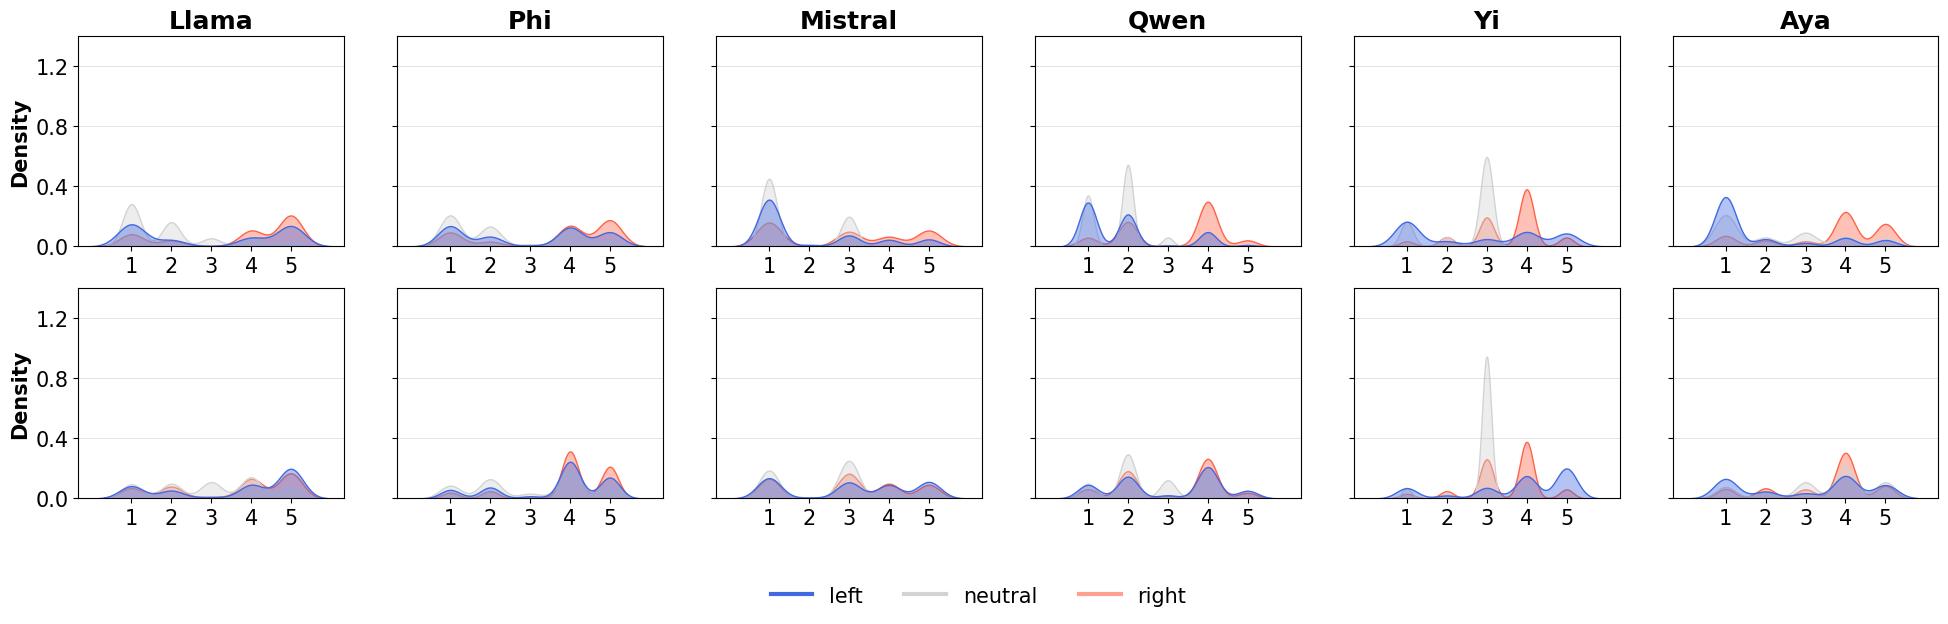

In [65]:
fig, axes = plt.subplots(2, 6, figsize=(24, 6), sharex=True, sharey=True)
for ax in axes[0, :]:  # top row
    ax.tick_params(labelbottom=True)
datasets = [
    ("Persuasion", data_propaganda),
    ("No persuasion", data_nopropaganda)
]

for r, (row_label, data) in enumerate(datasets):

    for c, model in enumerate(MODELS):

        ax = axes[r, c]
        sub = data[data["model"] == model]

        plot_general(sub, ax=ax, ylim_low=0, ylim_high=1.4)

        ax.set_xlabel("")
        ax.set_xticks(range(1,6))
        ax.set_xticklabels(range(1,6), fontsize=15)

        if r == 0:
            ax.set_title(dictionary_models.get(model, model), fontsize=18, fontweight="bold")
            
        if c == 0:
            ax.set_ylabel('Density', fontsize=15, fontweight="bold")
            ax.set_yticks([x/10 for x in range(0,16,4)])
            ax.set_yticklabels([x/10 for x in range(0,16,4)], fontsize = 15)
            #ax.tick_params(axis = 'y', labelsize = 15)
        else:
            ax.set_ylabel("")

        ax.grid(
        axis='y',
        linestyle='-',
        linewidth=0.5,
        alpha=0.5
        )

from matplotlib.lines import Line2D

legend_elements = [
    Line2D([0], [0], color='royalblue', lw=3, label='left'),
    Line2D([0], [0], color='lightgrey', lw=3, label='neutral'),
    Line2D([0], [0], color='tomato', lw=3, label='right', alpha =0.6),
]

fig.legend(
    handles=legend_elements,
    loc='lower center',
    ncol=3,
    frameon=False,
    bbox_to_anchor=(0.5, -0.1), 
    fontsize=15
)

plt.savefig("../figures/tweets_kde_both.pdf",bbox_inches = 'tight')

## technique aware

In [67]:
data_propaganda_tecniquegrouped = {s:sub.reset_index(drop=True) for s,sub in data_propaganda.groupby('propaganda_category')}
tecs = sorted(list(data_propaganda_tecniquegrouped.keys()))
#models = {}
rand_rows_all = []
#tecs


In [68]:
models = {}
rand_rows_all = []
for tec in tecs:
    print(f"****** {tec} ******")

    prop_df = data_propaganda_tecniquegrouped[tec].copy()
    no_prop_df = data_nopropaganda.copy()

    prop_df["type_p"] = "propaganda"
    no_prop_df["type_p"] = "nopropaganda"

    prop_texts = prop_df["text_normalized"].drop_duplicates()
    no_prop_texts = no_prop_df["text_normalized"].drop_duplicates()

    n = min(len(prop_texts), len(no_prop_texts))

    sampled_prop_texts = prop_texts.sample(n=n, random_state=42)
    sampled_no_prop_texts = no_prop_texts.sample(n=n, random_state=42)

    prop_sampled = prop_df[prop_df["text_normalized"].isin(sampled_prop_texts)].copy()
    no_prop_sampled = no_prop_df[no_prop_df["text_normalized"].isin(sampled_no_prop_texts)].copy()

    print(
        f"unique NP texts: {no_prop_sampled['text_normalized'].nunique()} - "
        f"unique {tec} texts: {prop_sampled['text_normalized'].nunique()}"
    )
    print(
        f"rows NP: {len(no_prop_sampled)} - "
        f"rows {tec}: {len(prop_sampled)}"
    )

    df_all = pd.concat([prop_sampled, no_prop_sampled], ignore_index=True)

    df_all["propaganda"] = (df_all["type_p"] == "propaganda").astype(int)

    df_all["condition"] = pd.Categorical(
        df_all["type"],
        categories=["neutral", "left", "right"],
        ordered=False
    )

    model = smf.mixedlm(
        "score ~ propaganda * condition",
        data=df_all,
        groups=df_all["model"],
        re_formula="~1"
    ).fit()

    fixed_intercept = model.fe_params["Intercept"]

    for m, re in model.random_effects.items():
        rand_rows_all.append({
            "technique": tec,
            "model": m,
            "random_intercept": re.iloc[0],
            "total_intercept": fixed_intercept + re.iloc[0]
        })

    models[tec] = model
    #print(model.summary())

rand_intercepts_df = pd.DataFrame(rand_rows_all)
rand_intercepts_df

****** appeal_to_fear_prejudice ******
unique NP texts: 489 - unique appeal_to_fear_prejudice texts: 489
rows NP: 8802 - rows appeal_to_fear_prejudice: 8802
****** loaded_language ******
unique NP texts: 734 - unique loaded_language texts: 734
rows NP: 13212 - rows loaded_language: 13212
****** name_calling_labelling ******
unique NP texts: 1068 - unique name_calling_labelling texts: 1068
rows NP: 19224 - rows name_calling_labelling: 19224
****** slogans ******
unique NP texts: 1574 - unique slogans texts: 1574
rows NP: 28332 - rows slogans: 28332


,technique,model,random_intercept,total_intercept
0,appeal_to_fear_prejudice,01-ai/Yi-1.5-9B-Chat,0.199668,3.149225
1,appeal_to_fear_prejudice,CohereForAI/aya-expanse-8b,-0.060901,2.888656
2,appeal_to_fear_prejudice,Qwen/Qwen2.5-7B-Instruct,-0.357435,2.592122
3,appeal_to_fear_prejudice,meta-llama/Llama-3.1-8B-Instruct,0.151773,3.101330
4,appeal_to_fear_prejudice,microsoft/Phi-3.5-mini-instruct,0.418336,3.367893
5,appeal_to_fear_prejudice,mistralai/Mistral-7B-Instruct-v0.3,-0.351441,2.598116
6,loaded_language,01-ai/Yi-1.5-9B-Chat,0.273843,3.233501
7,loaded_language,CohereForAI/aya-expanse-8b,-0.047251,2.912407
8,loaded_language,Qwen/Qwen2.5-7B-Instruct,-0.438693,2.520965
9,loaded_language,meta-llama/Llama-3.1-8B-Instruct,0.266371,3.226029


In [69]:
rand_intercepts_df["model_name"] = rand_intercepts_df["model"].map(dictionary_models)

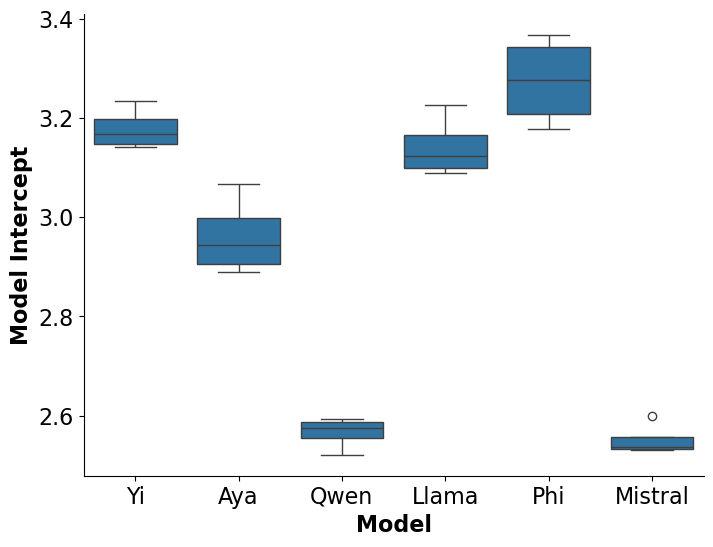

In [70]:
plt.figure(figsize=(8,6))

sns.boxplot(
    data=rand_intercepts_df,
    x="model_name",
    y="total_intercept",
)

plt.ylabel("Model Intercept", fontsize=16, fontweight="bold")
plt.xlabel("Model", fontsize=16, fontweight="bold")

plt.xticks(fontsize=16)
plt.yticks(fontsize=16)

sns.despine()

plt.savefig("../figures/tweets_boxplot_intercepts.png")  

In [71]:
pred_rows = []

for tec in tecs:

    m = models[tec]
    fe = m.fe_params

    rand_df_tec = rand_intercepts_df[rand_intercepts_df["technique"] == tec]

    for _, ri in rand_df_tec.iterrows():
        model_name = ri["model"]
        rand_int = ri["random_intercept"]

        for prop_flag in [0,1]:
            for cond in ["neutral","left","right"]:

                val = fe["Intercept"] + rand_int

                if cond == "left":
                    val += fe.get("condition[T.left]",0)
                elif cond == "right":
                    val += fe.get("condition[T.right]",0)

                if prop_flag == 1:
                    val += fe.get("propaganda",0)

                    if cond == "left":
                        val += fe.get("propaganda:condition[T.left]",0)
                    elif cond == "right":
                        val += fe.get("propaganda:condition[T.right]",0)

                pred_rows.append({
                    "technique": tec,
                    "model": model_name,
                    "propaganda": prop_flag,
                    "condition": cond,
                    "prediction": val
                })

pred_df = pd.DataFrame(pred_rows)



In [72]:
intercept = np.array([ models[tec].fe_params['Intercept'] for tec in tecs])
cond_left = np.array([ models[tec].fe_params['condition[T.left]'] for tec in tecs])
cond_right = np.array([ models[tec].fe_params['condition[T.right]'] for tec in tecs])
prop = np.array([ models[tec].fe_params['propaganda'] for tec in tecs])
prop_left = np.array([ models[tec].fe_params['propaganda:condition[T.left]'] for tec in tecs])

prop_right = np.array([ models[tec].fe_params['propaganda:condition[T.right]'] for tec in tecs])

In [73]:
import pandas as pd

df_params = pd.DataFrame(
    {
        "Intercept": intercept,
        "cons_left": cond_left,
        "cond_right": cond_right,
        "propaganda": prop,
        "prop_left": prop_left,
        "prop_right": prop_right,
    },
    index=tecs
)

df_params.index.name = "techniques"
df_params

,Intercept,cons_left,cond_right,propaganda,prop_left,prop_right
techniques,,,,,,
appeal_to_fear_prejudice,2.949557,0.487844,0.486026,-0.501193,-0.254033,0.661611
loaded_language,2.959658,0.471314,0.487133,-0.583485,-0.157206,0.780957
name_calling_labelling,2.946057,0.469777,0.466604,-1.005722,-0.040782,0.860617
slogans,2.924996,0.448821,0.493859,-0.945962,-0.199809,0.917326


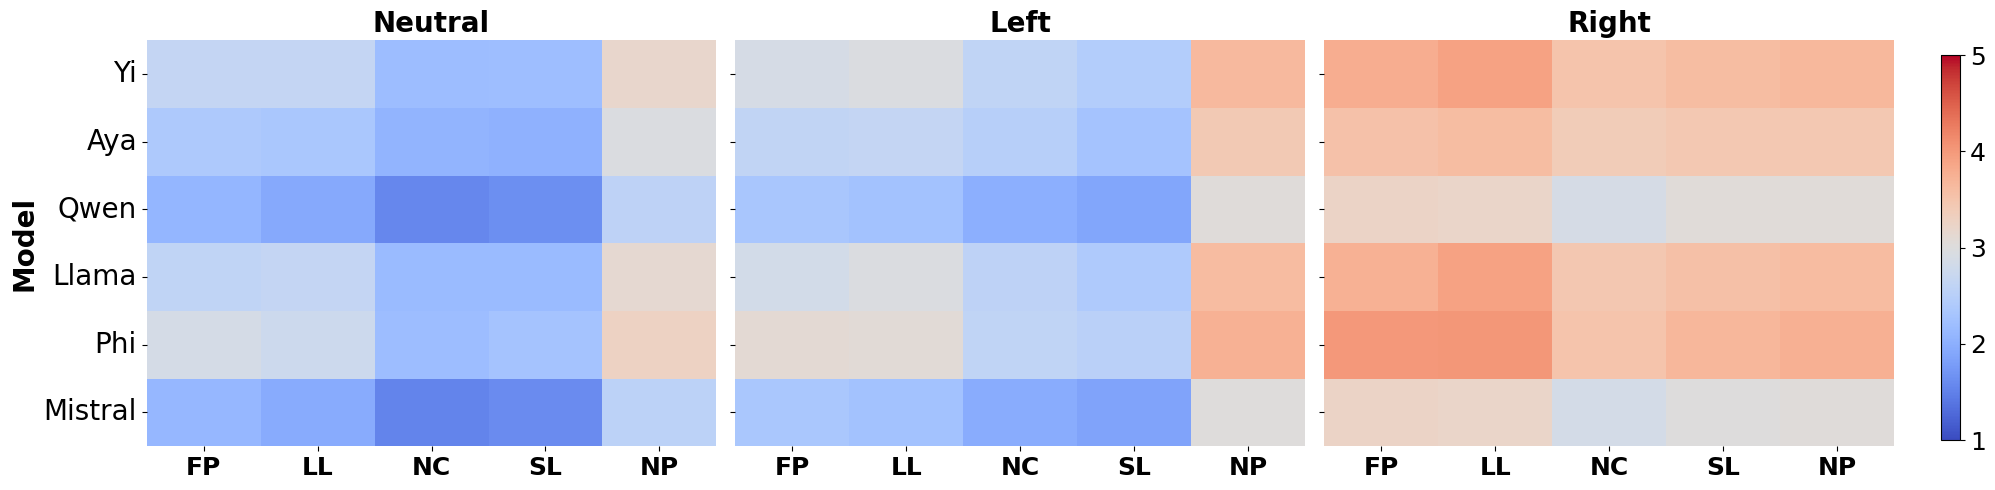

In [74]:
conds = ["neutral", "left", "right"]

fig, axes = plt.subplots(1, 3, figsize=(22, 5), sharex=True, sharey=True)

for c, cond in enumerate(conds):

    ax = axes[c]

    # propaganda rows: model x technique
    sub_prop = pred_df[
        (pred_df["propaganda"] == 1) &
        (pred_df["condition"] == cond)
    ]

    heat = sub_prop.pivot(
        index="model",
        columns="technique",
        values="prediction"
    )

    # no-propaganda average per model, aggregated over techniques
    sub_noprop = pred_df[
        (pred_df["propaganda"] == 0) &
        (pred_df["condition"] == cond)
    ]

    noprop_avg = (
        sub_noprop
        .groupby("model")["prediction"]
        .mean()
        .rename("no_propaganda")
    )

    # add as extra column
    heat = heat.join(noprop_avg)

    tech_map = {
    "appeal_to_fear_prejudice": "FP",
    "loaded_language": "LL",
    "name_calling_labelling": "NC",
    "slogans": "SL",
    "no_propaganda": "NP"}
    heat = heat.rename(columns=tech_map, index=dictionary_models)
    
    sns.heatmap(
        heat,
        cmap="coolwarm",
        ax=ax,
        annot=False,
        fmt=".2f",
        cbar=False,
        vmin = 1, vmax = 5
    )

    ax.set_title(f"{cond.title()}", size=20, weight = 'bold')
    ax.set_xlabel("")
    ax.set_ylabel("model" if c == 0 else "", size = 20)
    ax.set_xticklabels(ax.get_xticklabels(),fontsize=18,fontweight="bold")
    #ax.set_yticklabels(ax.get_yticklabels(),fontsize=10,fontweight="bold")
    
    # find NP column index
    np_col_idx = list(heat.columns).index("NP")

    # draw rectangle (x, y, width, height)
    # ax.add_patch(
    #     plt.Rectangle(
    #         (np_col_idx, 0),          # start at column position
    #         1,                        # width = 1 column
    #         heat.shape[0],            # full height
    #         fill=False,
    #         edgecolor="black",
    #         lw=2
    #     )
    # )
# get the mappable from the last heatmap
mappable = ax.collections[0]

# add a single colorbar for the whole figure
cbar = fig.colorbar(mappable, ax=axes, fraction=0.02, pad=0.02)
cbar.set_ticks([1, 2, 3, 4, 5])
cbar.ax.tick_params(labelsize=18)
#cbar.set_label("Prediction score", fontsize=12)

ax0 = axes[0]  # first subplot

for label in ax0.get_yticklabels():
    label.set_fontsize(20)
    label.set_rotation(0)
ax0.set_ylabel("Model", fontsize=20, fontweight="bold")
    
plt.tight_layout(rect=[0, 0, 0.87, 1]) 
# legend_text = (
#     "Techniques:\n"
#     "FP = appeal to fear/prejudice\n"
#     "LL = loaded language\n"
#     "NCL = name calling/labelling\n"
#     "SL = slogans\n"
#     "NP = no propaganda"
# )

# fig.text(
#     1.02, 0.5,
#     legend_text,
#     fontsize=11,
#     va="center"
# )
plt.savefig("../figures/tweets_technique_heatmaps_horizontal.pdf",bbox_inches = 'tight')
plt.show()

## topics

In [75]:
tweets_topic_source = balanced_df.copy()

tweets_topic_source["topic_text"] = clean_text_series(
    tweets_topic_source["text_normalized"]
    if "text_normalized" in tweets_topic_source.columns
    else tweets_topic_source["text"]
)

min_cl_size = 75

tweets_with_topics, tweets_unique_texts, tweets_topic_model = fit_topics_on_unique_texts(
    tweets_topic_source,
    text_col="topic_text",
    vectorizer_model=TWEETS_VECTORIZER,
    seed=SEED,
    min_cluster_size=min_cl_size,
    cache_path=f"cache/tweets_topics_{min_cl_size}.pkl",
)

tweet_topic_labels = topic_keyword_labels(tweets_topic_model, top_n=4)
tweet_topic_labels

Loading cached topics from cache/tweets_topics_75.pkl


,topic,topic_label
0,0,"mariupol, istandwithputin, istandwithrussia, u..."
1,1,"ukrainian, hitler, ukrainians, nazis ukraine"
2,2,"media, ukrainian, western, ukrainian propaganda"
3,3,"media, rt, western, ve"
4,4,"fox, western, tucker, media"
5,5,"nato, threat, finland, military"
6,6,"zelensky, zelenskyy, jewish, president"
7,7,"azov, battalion, azov battalion, neonazi"
8,8,"hitler, nuclear, war putin, world"
9,9,"donbass, genocide, donbas, ukrainian"


In [76]:
tweets_topic_balanced = balance_topics_by_propaganda(
    tweets_with_topics,
    text_col="text_normalized",
    propaganda_col="has_propaganda",
    topic_col="topic",
    condition_col=TWEETS_CONDITION_COL,
    random_state=SEED,
)

tweets_topic_model_df = prepare_model_data(
    tweets_topic_balanced,
    condition_col=TWEETS_CONDITION_COL,
    consider_topic=True,
)

print(tweets_topic_model_df.groupby(["topic", "type"]).size().unstack(fill_value=0).head(20))

# Optional global topic-adjusted model.
tweets_topic_adjusted_model = fit_topic_adjusted_mixed_model(
    tweets_topic_model_df,
    condition_col=TWEETS_CONDITION_COL,
)
print(tweets_topic_adjusted_model.summary())

tweets_topic_models = fit_topic_models(
    tweets_topic_model_df,
    condition_col=TWEETS_CONDITION_COL,
    min_rows=100,
)
tweets_effects = topic_effects_table(tweets_topic_models, condition_col=TWEETS_CONDITION_COL)
tweets_effects.head()


Using `type` as condition column.
type
neutral    16620
left       16620
right      16620
Name: count, dtype: int64
type   neutral  left  right
topic                      
0         4692  4692   4692
1         1296  1296   1296
2         1116  1116   1116
3         1452  1452   1452
4          924   924    924
5         1200  1200   1200
6          588   588    588
7          396   396    396
8          888   888    888
9          612   612    612
10         960   960    960
11         900   900    900
12         456   456    456
13         636   636    636
14         108   108    108
15         252   252    252
16         144   144    144
Formula: score ~ has_propaganda * type + C(topic)
                 Mixed Linear Model Regression Results
Model:                 MixedLM      Dependent Variable:      score      
No. Observations:      49860        Method:                  ML         
No. Groups:            6            Scale:                   1.7149     
Min. group size:       8310 

,topic,neutral_no_prop,neutral_prop,left_no_prop,left_prop,right_no_prop,right_prop
0,0,3.214265,2.035521,3.624609,1.986502,3.479540,3.534598
1,1,2.569444,2.079733,3.073045,2.546811,3.146605,3.261317
2,2,2.884707,2.408602,3.394863,2.550179,3.544803,3.718041
3,3,2.857208,2.598255,3.348944,2.943526,3.434343,3.738292
4,4,2.887446,2.287879,3.220779,2.845599,3.532468,3.421356


In [77]:
from dotenv import load_dotenv
load_dotenv('./apikey.env')

True

In [78]:
import json
import os
from pathlib import Path

import pandas as pd
import requests


def load_cache(cache_file: str | os.PathLike = "topic_labels_cache.json") -> dict:
    """Load topic-label cache from disk."""
    cache_path = Path(cache_file)
    if cache_path.exists():
        with cache_path.open("r", encoding="utf-8") as f:
            return json.load(f)
    return {}


def save_cache(cache: dict, cache_file: str | os.PathLike = "topic_labels_cache.json") -> None:
    """Persist topic-label cache to disk."""
    cache_path = Path(cache_file)
    cache_path.parent.mkdir(parents=True, exist_ok=True)
    with cache_path.open("w", encoding="utf-8") as f:
        json.dump(cache, f, indent=2, ensure_ascii=False)


def make_topic_cache_key(
    topic_id: int,
    keywords: str,
    model: str,
    dataset_name: str = "default",
) -> str:
    payload = {
        "dataset_name": dataset_name,
        "topic_id": int(topic_id),
        "keywords": keywords,
        "model": model,
    }
    return json.dumps(payload, sort_keys=True, ensure_ascii=False)


def classify_with_openrouter(prompt: str, model: str = "openai/gpt-4o-mini") -> str:
    api_key = os.getenv("OPENROUTER_API_KEY")

    if not api_key:
        raise ValueError("Missing OPENROUTER_API_KEY environment variable.")

    response = requests.post(
        "https://openrouter.ai/api/v1/chat/completions",
        headers={
            "Authorization": f"Bearer {api_key.strip()}",
            "Content-Type": "application/json",
        },
        json={
            "model": model,
            "messages": [{"role": "user", "content": prompt}],
            "temperature": 0,
        },
        timeout=60,
    )

    response.raise_for_status()
    data = response.json()

    content = data.get("choices", [{}])[0].get("message", {}).get("content")

    if content is None:
        print("Warning: model returned no content.")
        print(data)
        return ""

    return content.strip()


def extract_keywords_from_topic_name(topic_name: str, top_n: int = 8) -> str:
    """
    Extract readable keywords from BERTopic get_topic_info()['Name'].
    Example: '3_covid_vaccine_health_people' -> 'covid, vaccine, health, people'
    """
    if not isinstance(topic_name, str) or not topic_name.strip():
        return ""

    parts = topic_name.split("_")

    if parts and parts[0].lstrip("-").isdigit():
        parts = parts[1:]

    return ", ".join(parts[:top_n])


def extract_keywords_from_representation(representation, top_n: int = 20) -> str:
    """Extract keywords from BERTopic get_topic_info()['Representation']."""
    if representation is None:
        return ""

    if isinstance(representation, list):
        return ", ".join([str(w) for w in representation[:top_n]])

    if isinstance(representation, str):
        representation = representation.strip("[]")
        parts = [p.strip().strip("'").strip('"') for p in representation.split(",")]
        return ", ".join(parts[:top_n])

    return str(representation)


def get_topic_keywords_from_info(topic_model, top_n: int = 20) -> pd.DataFrame:
    topic_info = topic_model.get_topic_info()
    rows = []

    for _, row in topic_info.iterrows():
        topic_id = row["Topic"]
        if topic_id == -1:
            continue

        rows.append({
            "topic_original": topic_id,
            "original_keywords": extract_keywords_from_representation(row["Representation"], top_n=top_n),
        })

    return pd.DataFrame(rows)


def get_topic_keywords_from_model(topic_model, top_n: int = 50) -> pd.DataFrame:
    rows = []

    for topic_id in topic_model.get_topic_info()["Topic"]:
        if topic_id == -1:
            continue

        words = topic_model.get_topic(topic_id)
        keywords = "" if not words else ", ".join([w for w, _ in words[:top_n]])

        rows.append({
            "topic_original": topic_id,
            "original_keywords": keywords,
        })

    return pd.DataFrame(rows)


def clean_llm_label(label: str) -> str:
    if not isinstance(label, str):
        return ""

    label = label.strip().replace('"', "").replace("'", "")
    label = label.replace(".", "").replace(":", "")
    return " ".join(label.split()[:2])


def prompt_topic_label(topic_id: int, keywords: str, docs: list[str]) -> str:
    docs_text = "\n\n".join([f"- {doc}" for doc in docs])

    return f"""
I have a topic from a propaganda/LLM endorsement dataset.

Topic ID: {topic_id}

Topic keywords:
{keywords}

Example documents:
{docs_text}

Based on the keywords and example documents, give a short label for the topic.

Rules:
- max 2 words
- no punctuation
- no explanation
- return only the label
""".strip()


def build_topic_label_table(
    df_with_topics: pd.DataFrame,
    topic_model,
    text_col: str = "text",
    topic_col: str = "topic",
    n_docs: int = 20,
    random_state: int = 42,
    force_recompute: bool = False,
    external_keywords: pd.DataFrame | None = None,
    cache_file: str | os.PathLike = "topic_labels_cache.json",
    openrouter_model: str = "openai/gpt-4o-mini",
    dataset_name: str = "default",
    refresh_cache: bool = False,
) -> pd.DataFrame:
    """Build a topic-label table with disk caching for LLM-generated labels.

    The cache prevents repeated OpenRouter calls when rerunning the notebook.
    Set refresh_cache=True to regenerate labels and overwrite cached values.
    """
    topic_info = topic_model.get_topic_info()
    cache = load_cache(cache_file)
    cache_changed = False


    rows = []

    topic_ids = sorted([
        int(t) for t in df_with_topics[topic_col].dropna().unique()
        if int(t) != -1
    ])

    for topic_id in topic_ids:
        subdf = df_with_topics[df_with_topics[topic_col] == topic_id]

        unique_docs = (
            subdf[text_col]
            .dropna()
            .drop_duplicates()
            .astype(str)
        )

        sampled_docs = (
            unique_docs.sample(
                n=min(n_docs, len(unique_docs)),
                random_state=random_state,
            )
            .tolist()
        )

        topic_row = topic_info[topic_info["Topic"] == topic_id]
        topic_name = topic_row.iloc[0]["Name"] if not topic_row.empty else ""

        if external_keywords is not None:
            kw_row = external_keywords[external_keywords["topic"] == topic_id]
            keywords = kw_row.iloc[0]["merged_original_keywords"] if not kw_row.empty else ""
        else:
            keywords = extract_keywords_from_topic_name(topic_name)

        prompt = prompt_topic_label(topic_id=topic_id, keywords=keywords, docs=sampled_docs)
        #cache_key = make_topic_cache_key(topic_id, keywords, sampled_docs, openrouter_model)
        cache_key = make_topic_cache_key(
            topic_id=topic_id,
            keywords=keywords,
            model=openrouter_model,
            dataset_name=dataset_name,
        )
        if not force_recompute and (cache_key in cache and not refresh_cache):
            label = cache[cache_key]
            print(f"Labeling topic {topic_id}: using cache -> {label}")
        else:
            print(f"Labeling topic {topic_id}: calling OpenRouter...")
            try:
                #label = clean_llm_label(classify_with_openrouter(prompt, model=openrouter_model))
                raw_label = classify_with_openrouter(prompt, model=openrouter_model)
                label = clean_llm_label(raw_label)

                if not label:
                    retry_prompt = prompt + "\n\nIMPORTANT: Return exactly one or two words. Do not return an empty answer."
                    raw_label = classify_with_openrouter(retry_prompt, model=openrouter_model)
                    label = clean_llm_label(raw_label)

                if not label:
                    label = clean_llm_label(keywords)

                cache[cache_key] = label
                cache_changed = True
                save_cache(cache, cache_file)
            except Exception as e:
                print(f"Error on topic {topic_id}: {e}")
                label = ""

        rows.append({
            "topic": topic_id,
            "bertopic_name": topic_name,
            "topic_keywords": keywords,
            "llm_label": label,
            "n_docs": len(subdf),
        })

    if cache_changed:
        save_cache(cache, cache_file)

    return pd.DataFrame(rows)


In [79]:
original_topic_keywords = get_topic_keywords_from_model(
    tweets_topic_model,
    top_n=50
)


In [80]:
original_topic_keywords = original_topic_keywords.rename(columns = {'topic_original':'topic', 'original_keywords':'merged_original_keywords'})
original_topic_keywords

,topic,merged_original_keywords
0,0,"mariupol, istandwithputin, istandwithrussia, u..."
1,1,"ukrainian, hitler, ukrainians, nazis ukraine, ..."
2,2,"media, ukrainian, western, ukrainian propagand..."
3,3,"media, rt, western, ve, russian media, west, b..."
4,4,"fox, western, tucker, media, western propagand..."
5,5,"nato, threat, finland, military, nuclear, cris..."
6,6,"zelensky, zelenskyy, jewish, president, peace,..."
7,7,"azov, battalion, azov battalion, neonazi, azov..."
8,8,"hitler, nuclear, war putin, world, putin nt, t..."
9,9,"donbass, genocide, donbas, ukrainian, killed, ..."


In [81]:
tweet_topic_labels_llm = build_topic_label_table(
    tweets_with_topics,
    tweets_topic_model,
    text_col="topic_text",
    topic_col="topic",
    n_docs=20,
    cache_file="cache/tweet_topic_labels_cache.json",
    force_recompute = False,
    dataset_name="tweets",
    openrouter_model="openai/gpt-4o-mini",
    refresh_cache=False,
)

Labeling topic 0: using cache -> Russia Ukraine
Labeling topic 1: using cache -> Ukrainian Nazis
Labeling topic 2: using cache -> media propaganda
Labeling topic 3: using cache -> Russian propaganda
Labeling topic 4: using cache -> media propaganda
Labeling topic 5: using cache -> NATO Threat
Labeling topic 6: using cache -> Zelensky Criticism
Labeling topic 7: using cache -> Azov Nazis
Labeling topic 8: using cache -> Putin Hitler
Labeling topic 9: using cache -> Donbass Genocide
Labeling topic 10: using cache -> Nazi Propaganda
Labeling topic 11: using cache -> Ukraine War
Labeling topic 12: using cache -> EU sanctions
Labeling topic 13: using cache -> Biden Crisis
Labeling topic 14: using cache -> Trump DOJ
Labeling topic 15: using cache -> China Taiwan
Labeling topic 16: using cache -> Nazi Ukraine


In [82]:
tweet_topic_labels_llm.loc[2, "llm_label"] = "ukrainian propaganda"

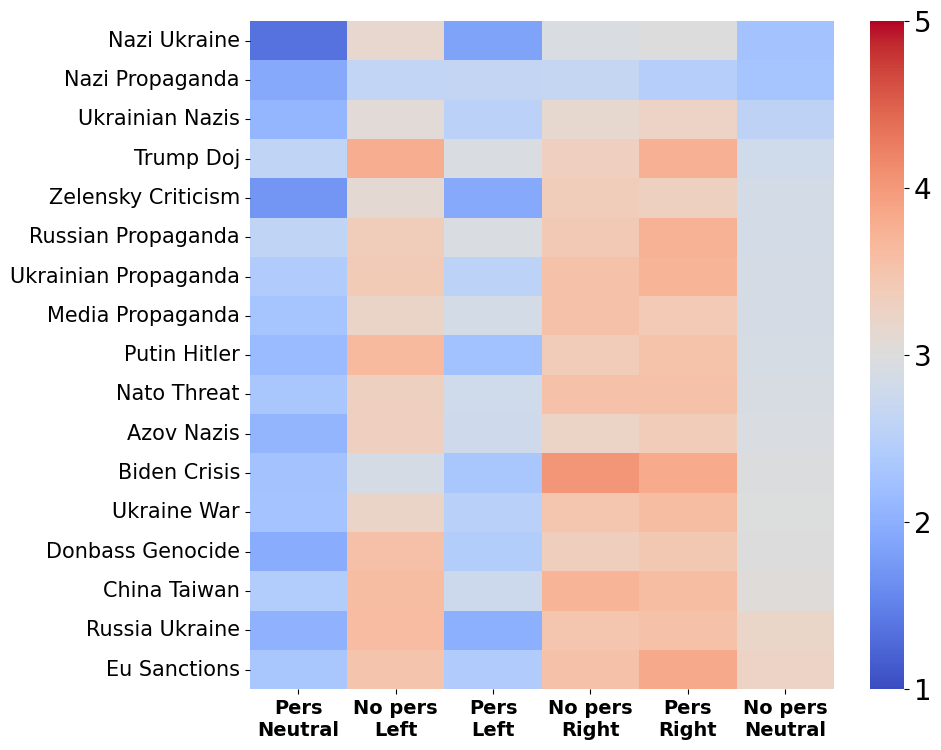

In [85]:
plot_topic_score_heatmap(
    tweets_effects,
    tweet_topic_labels_llm,
    title="Tweets topic effects",
    output_path="../figures/tweet_topics_heatmap.pdf",
)

# NEWS

## data

In [98]:
df_news = pd.read_csv('../span_news_all.csv')
len(df_news)

12625

In [32]:
l,r,n = load_datasets(folder = './generations/merged_news_seed', prefix = 'news_seedaggregated')
r = r.rename(columns={"label": "propaganda_category", 'score_avg':'score'})
l = l.rename(columns={"label": "propaganda_category", 'score_avg':'score'})
n = n.rename(columns={"label": "propaganda_category", 'score_avg':'score'})

data = combine_wings([l,r,n], include_neutral=True)

NO_PROPAGANDA_LABELS = {"no_propaganda", "none"}
data["has_propaganda"] = (~data['propaganda_category'].astype(str).isin(NO_PROPAGANDA_LABELS)).astype(int)
data = data[data['model'].isin(MODELS)]
data_sel = data[data['propaganda_category'].isin(TECHNIQUES)]
print(len(data))
data.groupby('model').size()

212040


model
01-ai/Yi-1.5-9B-Chat                  35340
CohereForAI/aya-expanse-8b            35340
Qwen/Qwen2.5-7B-Instruct              35340
meta-llama/Llama-3.1-8B-Instruct      35340
microsoft/Phi-3.5-mini-instruct       35340
mistralai/Mistral-7B-Instruct-v0.3    35340
dtype: int64

In [101]:
l.text.nunique(), len(data)/18, len(data_sel)/18

(11780, 11780.0, 8698.0)

In [102]:
# from l, get a subset that is l but only with unique texts (drop duplicates based on text column)
l_sub = l.drop_duplicates(subset=['text'])
l_sub.text.nunique()

11780

In [103]:
l_sub["n_techniques"] = l_sub["propaganda_category"].apply(lambda x: 1 if x == "no_propaganda" else len(x.split(",")))

In [104]:
l_sub = l_sub[l_sub["n_techniques"] == 1].copy()

In [105]:
l_sub["propaganda_category"].value_counts()

propaganda_category
no_propaganda                      6932
Loaded_Language                    1088
Name_Calling-Labeling               428
Doubt                               318
Repetition                          272
Appeal_to_Fear-Prejudice            179
Exaggeration-Minimisation           142
Flag_Waving                         136
Appeal_to_Authority                  82
False_Dilemma-No_Choice              75
Slogans                              71
Causal_Oversimplification            71
Conversation_Killer                  53
Red_Herring                          28
Appeal_to_Popularity                 22
Guilt_by_Association                 19
Appeal_to_Hypocrisy                  17
Obfuscation-Vagueness-Confusion      16
Straw_Man                            12
Whataboutism                          4
Name: count, dtype: int64

In [108]:
news_balanced = balance_propaganda_classes(
    data_sel,
    text_col="text",
    propaganda_col="has_propaganda",
    condition_col="type",
    random_state=42
)

data_propaganda = news_balanced[news_balanced["has_propaganda"] == 1].copy()
data_nopropaganda = news_balanced[news_balanced["has_propaganda"] == 0].copy()

len(data_propaganda), len(data_nopropaganda), len(data_propaganda)/18


(31788, 31788, 1766.0)

In [109]:
TECHNIQUES

{'Appeal_to_Fear-Prejudice',
 'Loaded_Language',
 'Name_Calling-Labeling',
 'Slogans',
 'no_propaganda'}

In [111]:
news_model_df = prepare_model_data(news_balanced, condition_col=NEWS_CONDITION_COL)

#news_model_df.groupby(["type"]).size().unstack(fill_value=0).head(20)


Using `type` as condition column.
type
neutral    21192
left       21192
right      21192
Name: count, dtype: int64


In [112]:
news_global_model = fit_global_mixed_model(
    news_model_df,
    condition_col=NEWS_CONDITION_COL,
    include_topics=False,
)
print(news_global_model.summary())


Formula: score ~ has_propaganda * type
                 Mixed Linear Model Regression Results
Model:                  MixedLM     Dependent Variable:     score      
No. Observations:       63576       Method:                 ML         
No. Groups:             6           Scale:                  1.1861     
Min. group size:        10596       Log-Likelihood:         -95656.5180
Max. group size:        10596       Converged:              Yes        
Mean group size:        10596.0                                        
-----------------------------------------------------------------------
                             Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-----------------------------------------------------------------------
Intercept                     3.179    0.115 27.710 0.000  2.954  3.404
type[T.left]                 -0.029    0.015 -1.942 0.052 -0.058  0.000
type[T.right]                 0.210    0.015 14.051 0.000  0.181  0.240
has_propaganda               -0.127    0.0

In [121]:
fixed = news_global_model.fe_params["Intercept"]
all_intercept = news_global_model.fe_params
print("fixed: ", round(fixed,3))
for k,v in all_intercept.items():
    if k=='Intercept': continue
    print(k, v, round(v+fixed,3))

fixed:  3.179
type[T.left] -0.029057861593931446 3.15
type[T.right] 0.2102452297193524 3.389
has_propaganda -0.12723012785792792 3.051
has_propaganda:type[T.left] 0.012510736892786468 3.191
has_propaganda:type[T.right] 0.28807174523975093 3.467


In [114]:
fixed_intercept = news_global_model.fe_params["Intercept"]
rand_rows_all = []
for m, re in news_global_model.random_effects.items():
    rand_rows_all.append({
        "model": m,
        "random_intercept": re.iloc[0],
        "total_intercept": fixed_intercept + re.iloc[0]
    })

In [118]:
rand_intercepts_df = pd.DataFrame(rand_rows_all)
rand_intercepts_df["model_name"] = rand_intercepts_df["model"].map(dictionary_models)
rand_intercepts_df["total_intercept"] = rand_intercepts_df["total_intercept"].round(3)
rand_intercepts_df.sort_values('total_intercept')

,model,random_intercept,total_intercept,model_name
2,Qwen/Qwen2.5-7B-Instruct,-0.320435,2.858,Qwen
5,mistralai/Mistral-7B-Instruct-v0.3,-0.249566,2.929,Mistral
1,CohereForAI/aya-expanse-8b,-0.141236,3.037,Aya
3,meta-llama/Llama-3.1-8B-Instruct,0.040679,3.219,Llama
0,01-ai/Yi-1.5-9B-Chat,0.172355,3.351,Yi
4,microsoft/Phi-3.5-mini-instruct,0.498203,3.677,Phi


## plot kde

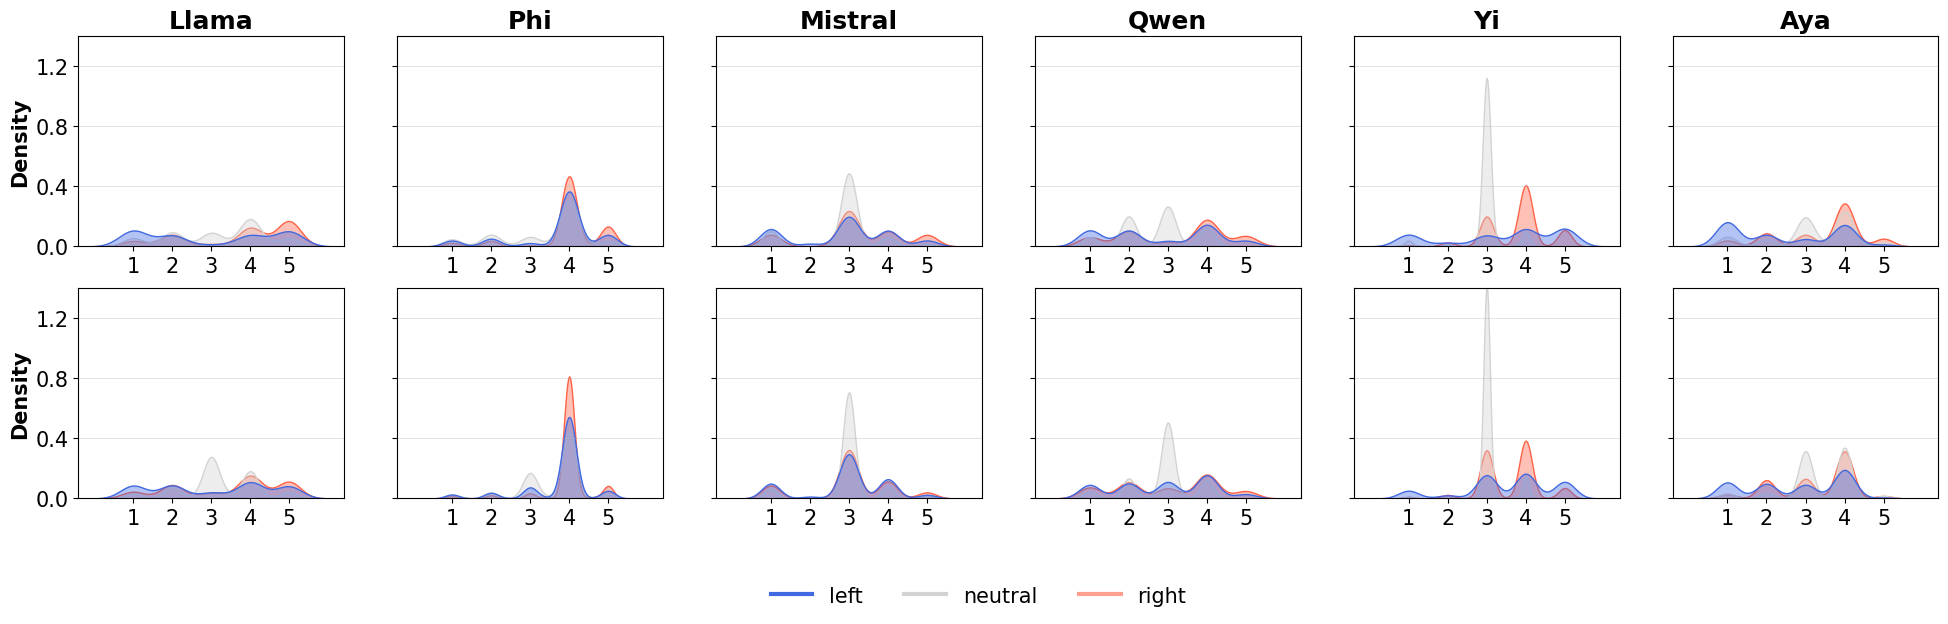

In [117]:
fig, axes = plt.subplots(2, 6, figsize=(24, 6), sharex=True, sharey=True)
for ax in axes[0, :]:  # top row
    ax.tick_params(labelbottom=True)
datasets = [
    ("Persuasion", data_propaganda),
    ("No persuasion", data_nopropaganda)
]

for r, (row_label, data) in enumerate(datasets):

    for c, model in enumerate(MODELS):

        ax = axes[r, c]
        sub = data[data["model"] == model]

        plot_general(sub, ax=ax, ylim_low=0, ylim_high=1.4)

        ax.set_xlabel("")
        ax.set_xticks(range(1,6))
        ax.set_xticklabels(range(1,6), fontsize=15)

        if r == 0:
            ax.set_title(dictionary_models.get(model, model), fontsize=18, fontweight="bold")
            
        if c == 0:
            ax.set_ylabel('Density', fontsize=15, fontweight="bold")
            ax.set_yticks([x/10 for x in range(0,16,4)])
            ax.set_yticklabels([x/10 for x in range(0,16,4)], fontsize = 15)
            #ax.tick_params(axis = 'y', labelsize = 15)
        else:
            ax.set_ylabel("")

        ax.grid(
        axis='y',
        linestyle='-',
        linewidth=0.5,
        alpha=0.5
        )

from matplotlib.lines import Line2D

legend_elements = [
    Line2D([0], [0], color='royalblue', lw=3, label='left'),
    Line2D([0], [0], color='lightgrey', lw=3, label='neutral'),
    Line2D([0], [0], color='tomato', lw=3, label='right', alpha =0.6),
]

fig.legend(
    handles=legend_elements,
    loc='lower center',
    ncol=3,
    frameon=False,
    bbox_to_anchor=(0.5, -0.1), 
    fontsize=15
)

plt.savefig("../figures/news_kde_both.pdf",bbox_inches = 'tight')

## technique aware

In [92]:
news_balanced = balance_propaganda_classes(
    data_sel,
    text_col="text",
    propaganda_col="has_propaganda",
    condition_col="type",
    random_state=42
)

data_propaganda = news_balanced[news_balanced["has_propaganda"] == 1].copy()
data_nopropaganda = news_balanced[news_balanced["has_propaganda"] == 0].copy()

len(data_propaganda), len(data_nopropaganda), len(data_propaganda)/18


(31788, 31788, 1766.0)

In [93]:
data_propaganda_tecniquegrouped = {s:sub.reset_index(drop=True) for s,sub in data_propaganda.groupby('propaganda_category')}
tecs = sorted(list(data_propaganda_tecniquegrouped.keys()))
#models = {}
rand_rows_all = []
#tecs


In [95]:
models = {}
rand_rows_all = []
for tec in tecs:
    print(f"****** {tec} ******")

    prop_df = data_propaganda_tecniquegrouped[tec].copy()
    no_prop_df = data_nopropaganda.copy()

    prop_df["type_p"] = "propaganda"
    no_prop_df["type_p"] = "nopropaganda"

    prop_texts = prop_df["text"].drop_duplicates()
    no_prop_texts = no_prop_df["text"].drop_duplicates()

    n = min(len(prop_texts), len(no_prop_texts))

    sampled_prop_texts = prop_texts.sample(n=n, random_state=42)
    sampled_no_prop_texts = no_prop_texts.sample(n=n, random_state=42)

    prop_sampled = prop_df[prop_df["text"].isin(sampled_prop_texts)].copy()
    no_prop_sampled = no_prop_df[no_prop_df["text"].isin(sampled_no_prop_texts)].copy()

    print(
        f"unique NP texts: {no_prop_sampled['text'].nunique()} - "
        f"unique {tec} texts: {prop_sampled['text'].nunique()}"
    )
    print(
        f"rows NP: {len(no_prop_sampled)} - "
        f"rows {tec}: {len(prop_sampled)}"
    )

    df_all = pd.concat([prop_sampled, no_prop_sampled], ignore_index=True)

    df_all["propaganda"] = (df_all["type_p"] == "propaganda").astype(int)

    df_all["condition"] = pd.Categorical(
        df_all["type"],
        categories=["neutral", "left", "right"],
        ordered=False
    )

    model = smf.mixedlm(
        "score ~ propaganda * condition",
        data=df_all,
        groups=df_all["model"],
        re_formula="~1"
    ).fit()

    fixed_intercept = model.fe_params["Intercept"]

    for m, re in model.random_effects.items():
        rand_rows_all.append({
            "technique": tec,
            "model": m,
            "random_intercept": re.iloc[0],
            "total_intercept": fixed_intercept + re.iloc[0]
        })

    models[tec] = model
    #print(model.summary())

rand_intercepts_df = pd.DataFrame(rand_rows_all)
rand_intercepts_df

****** Appeal_to_Fear-Prejudice ******
unique NP texts: 179 - unique Appeal_to_Fear-Prejudice texts: 179
rows NP: 3222 - rows Appeal_to_Fear-Prejudice: 3222
****** Loaded_Language ******
unique NP texts: 1088 - unique Loaded_Language texts: 1088
rows NP: 19584 - rows Loaded_Language: 19584
****** Name_Calling-Labeling ******
unique NP texts: 428 - unique Name_Calling-Labeling texts: 428
rows NP: 7704 - rows Name_Calling-Labeling: 7704
****** Slogans ******
unique NP texts: 71 - unique Slogans texts: 71
rows NP: 1278 - rows Slogans: 1278


,technique,model,random_intercept,total_intercept
0,Appeal_to_Fear-Prejudice,01-ai/Yi-1.5-9B-Chat,0.090269,3.270902
1,Appeal_to_Fear-Prejudice,CohereForAI/aya-expanse-8b,-0.004272,3.176361
2,Appeal_to_Fear-Prejudice,Qwen/Qwen2.5-7B-Instruct,-0.344678,2.835955
3,Appeal_to_Fear-Prejudice,meta-llama/Llama-3.1-8B-Instruct,0.033636,3.214270
4,Appeal_to_Fear-Prejudice,microsoft/Phi-3.5-mini-instruct,0.504035,3.684669
5,Appeal_to_Fear-Prejudice,mistralai/Mistral-7B-Instruct-v0.3,-0.278991,2.901642
6,Loaded_Language,01-ai/Yi-1.5-9B-Chat,0.167704,3.339452
7,Loaded_Language,CohereForAI/aya-expanse-8b,-0.159053,3.012694
8,Loaded_Language,Qwen/Qwen2.5-7B-Instruct,-0.324771,2.846976
9,Loaded_Language,meta-llama/Llama-3.1-8B-Instruct,0.039666,3.211413


In [107]:
rand_intercepts_df["model_name"] = rand_intercepts_df["model"].map(dictionary_models)

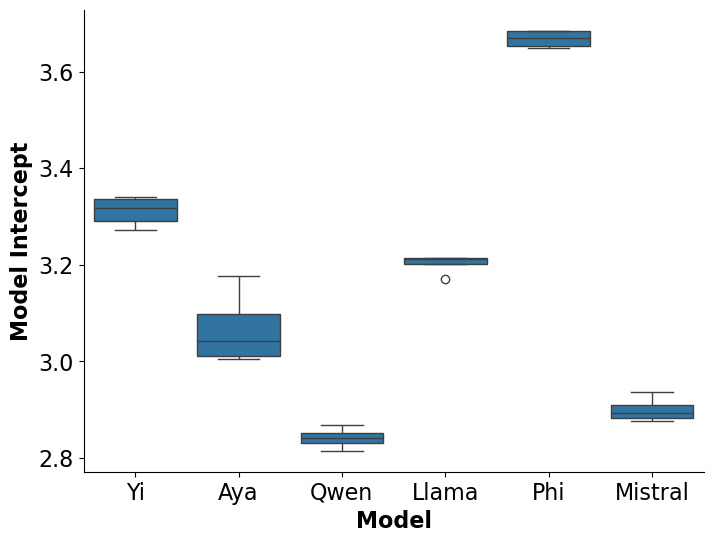

In [109]:
plt.figure(figsize=(8,6))

sns.boxplot(
    data=rand_intercepts_df,
    x="model_name",
    y="total_intercept",
)

plt.ylabel("Model Intercept", fontsize=16, fontweight="bold")
plt.xlabel("Model", fontsize=16, fontweight="bold")

plt.xticks(fontsize=16)
plt.yticks(fontsize=16)

sns.despine()

plt.savefig("../figures/news_boxplot_intercepts.png")  

In [110]:
pred_rows = []

for tec in tecs:

    m = models[tec]
    fe = m.fe_params

    rand_df_tec = rand_intercepts_df[rand_intercepts_df["technique"] == tec]

    for _, ri in rand_df_tec.iterrows():
        model_name = ri["model"]
        rand_int = ri["random_intercept"]

        for prop_flag in [0,1]:
            for cond in ["neutral","left","right"]:

                val = fe["Intercept"] + rand_int

                if cond == "left":
                    val += fe.get("condition[T.left]",0)
                elif cond == "right":
                    val += fe.get("condition[T.right]",0)

                if prop_flag == 1:
                    val += fe.get("propaganda",0)

                    if cond == "left":
                        val += fe.get("propaganda:condition[T.left]",0)
                    elif cond == "right":
                        val += fe.get("propaganda:condition[T.right]",0)

                pred_rows.append({
                    "technique": tec,
                    "model": model_name,
                    "propaganda": prop_flag,
                    "condition": cond,
                    "prediction": val
                })

pred_df = pd.DataFrame(pred_rows)



In [111]:
pred_df["technique"] = pred_df["technique"].apply(lambda x: x.lower())

In [112]:
intercept = np.array([ models[tec].fe_params['Intercept'] for tec in tecs])
cond_left = np.array([ models[tec].fe_params['condition[T.left]'] for tec in tecs])
cond_right = np.array([ models[tec].fe_params['condition[T.right]'] for tec in tecs])
prop = np.array([ models[tec].fe_params['propaganda'] for tec in tecs])
prop_left = np.array([ models[tec].fe_params['propaganda:condition[T.left]'] for tec in tecs])

prop_right = np.array([ models[tec].fe_params['propaganda:condition[T.right]'] for tec in tecs])

In [113]:
tecs = [tec.lower().replace("-", "_") for tec in tecs]

In [114]:
import pandas as pd

df_params = pd.DataFrame(
    {
        "Intercept": intercept,
        "cons_left": cond_left,
        "cond_right": cond_right,
        "propaganda": prop,
        "prop_left": prop_left,
        "prop_right": prop_right,
    },
    index=tecs
)

df_params.index.name = "techniques"
df_params

,Intercept,cons_left,cond_right,propaganda,prop_left,prop_right
techniques,,,,,,
appeal_to_fear_prejudice,3.180633,-0.095438,0.224395,-0.053383,0.117784,0.175357
loaded_language,3.171747,-0.048090,0.215976,-0.077002,0.026389,0.234724
name_calling_labeling,3.151610,-0.050948,0.232477,-0.241433,0.043030,0.406023
slogans,3.154930,-0.125196,0.315336,-0.105634,0.037559,0.316119


In [115]:
data_sel.propaganda_category.unique()

<ArrowStringArray>
[           'no_propaganda', 'Appeal_to_Fear-Prejudice',
                  'Slogans',          'Loaded_Language',
    'Name_Calling-Labeling']
Length: 5, dtype: str

In [116]:
pred_df["technique"] = pred_df["technique"].str.lower().str.replace("-", "_")

In [117]:
sub_prop = pred_df[
        (pred_df["propaganda"] == 1) &
        (pred_df["condition"] == cond)
    ]

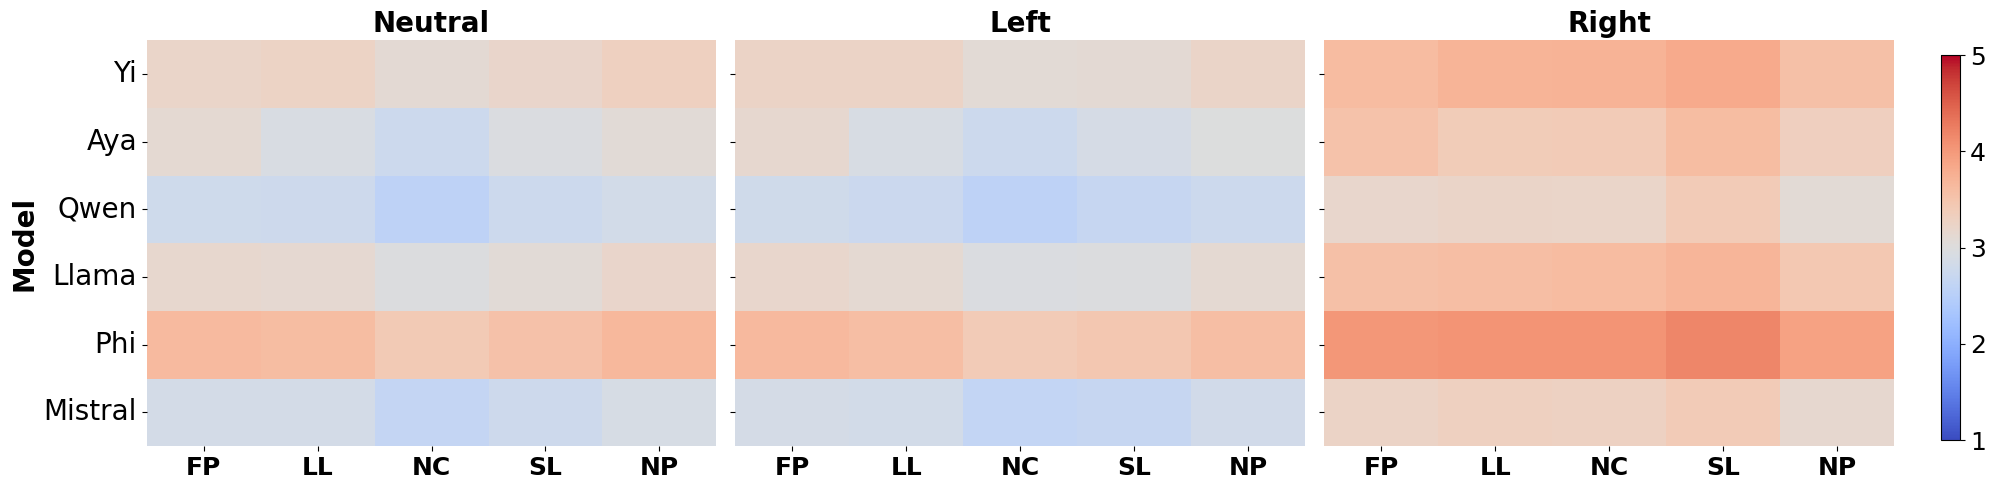

In [118]:
conds = ["neutral", "left", "right"]

fig, axes = plt.subplots(1, 3, figsize=(22, 5), sharex=True, sharey=True)

for c, cond in enumerate(conds):

    ax = axes[c]

    # propaganda rows: model x technique
    sub_prop = pred_df[
        (pred_df["propaganda"] == 1) &
        (pred_df["condition"] == cond)
    ]

    heat = sub_prop.pivot(
        index="model",
        columns="technique",
        values="prediction"
    )

    # no-propaganda average per model, aggregated over techniques
    sub_noprop = pred_df[
        (pred_df["propaganda"] == 0) &
        (pred_df["condition"] == cond)
    ]

    noprop_avg = (
        sub_noprop
        .groupby("model")["prediction"]
        .mean()
        .rename("no_propaganda")
    )

    # add as extra column
    heat = heat.join(noprop_avg)

    tech_map = {
    "appeal_to_fear_prejudice": "FP",
    "loaded_language": "LL",
    "name_calling_labeling": "NC",
    "slogans": "SL",
    "no_propaganda": "NP"}
    heat = heat.rename(columns=tech_map, index=dictionary_models)
    
    sns.heatmap(
        heat,
        cmap="coolwarm",
        ax=ax,
        annot=False,
        fmt=".2f",
        cbar=False,
        vmin = 1, vmax = 5
    )

    ax.set_title(f"{cond.title()}", size=20, weight = 'bold')
    ax.set_xlabel("")
    ax.set_ylabel("model" if c == 0 else "", size = 20)
    ax.set_xticklabels(ax.get_xticklabels(),fontsize=18,fontweight="bold")
    #ax.set_yticklabels(ax.get_yticklabels(),fontsize=10,fontweight="bold")
    
    # find NP column index
    np_col_idx = list(heat.columns).index("NP")

# get the mappable from the last heatmap
mappable = ax.collections[0]

# add a single colorbar for the whole figure
cbar = fig.colorbar(mappable, ax=axes, fraction=0.02, pad=0.02)
cbar.set_ticks([1, 2, 3, 4, 5])
cbar.ax.tick_params(labelsize=18)
#cbar.set_label("Prediction score", fontsize=12)

ax0 = axes[0]  # first subplot

for label in ax0.get_yticklabels():
    label.set_fontsize(20)
    label.set_rotation(0)
ax0.set_ylabel("Model", fontsize=20, fontweight="bold")
    
plt.tight_layout(rect=[0, 0, 0.87, 1]) 

plt.savefig("../figures/news_technique_heatmaps_horizontal.pdf",bbox_inches = 'tight')
plt.show()

## topics


In [119]:
news_topic_source = data_sel.copy()
news_topic_source["topic_text"] = clean_text_series(news_topic_source["text"])

min_cl_size=100

news_with_topics, news_unique_texts, news_topic_model = fit_topics_on_unique_texts(
    news_topic_source,
    text_col="topic_text",
    vectorizer_model=NEWS_VECTORIZER,
    seed=SEED,
    min_cluster_size=min_cl_size,
    cache_path=f"cache/news_topics_{min_cl_size}.pkl",
)

news_topic_labels = topic_keyword_labels(news_topic_model, top_n=4)
news_topic_labels

Loading cached topics from cache/news_topics_100.pkl


,topic,topic_label
0,0,"church, abuse, god, letter"
1,1,"report, investigation, trump, fbi"
2,2,"deal, uk, vote, britain"
3,3,"iran, regime, north, syria"
4,4,"muslim, islamic, israel, islam"
5,5,"allegations, court, supreme court, supreme"
6,6,"thats, let, question, im"
7,7,"las, shooting, ammunition, mass"
8,8,"permission, 2019, article, fox"
9,9,"arrested, immigration, illegal, criminal"


In [120]:
news_topic_balanced = balance_topics_by_propaganda(
    news_with_topics,
    text_col="topic_text",
    propaganda_col="has_propaganda",
    topic_col="topic",
    condition_col=NEWS_CONDITION_COL,
    random_state=SEED,
)

news_topic_model_df = prepare_model_data(
    news_topic_balanced,
    condition_col=NEWS_CONDITION_COL,
    consider_topic=True,
)

print(news_topic_model_df.groupby(["topic", "type"]).size().unstack(fill_value=0).head(20))

# Optional global topic-adjusted model.
news_topic_adjusted_model = fit_topic_adjusted_mixed_model(
    news_topic_model_df,
    condition_col=NEWS_CONDITION_COL,
)
print(news_topic_adjusted_model.summary())

news_topic_models = fit_topic_models(
    news_topic_model_df,
    condition_col=NEWS_CONDITION_COL,
    min_rows=100,
)
news_effects = topic_effects_table(news_topic_models, condition_col=NEWS_CONDITION_COL)
news_effects.head()


Using `type` as condition column.
type
neutral    16992
left       16992
right      16992
Name: count, dtype: int64
type   neutral  left  right
topic                      
0         4104  4104   4104
1         2544  2544   2544
2         2484  2484   2484
3         1188  1188   1188
4         1404  1404   1404
5         1164  1164   1164
6          336   336    336
7          192   192    192
8           36    36     36
9          444   444    444
10         360   360    360
11         420   420    420
12         336   336    336
13         420   420    420
14         612   612    612
15         384   384    384
16         264   264    264
17         264   264    264
18          36    36     36
Formula: score ~ has_propaganda * type + C(topic)
                 Mixed Linear Model Regression Results
Model:                 MixedLM      Dependent Variable:      score      
No. Observations:      50976        Method:                  ML         
No. Groups:            6            Scale:   

,topic,neutral_no_prop,neutral_prop,left_no_prop,left_prop,right_no_prop,right_prop
0,0,3.048408,2.982294,2.884462,2.841537,3.192333,3.460364
1,1,3.279743,3.120152,3.385875,3.185797,3.486504,3.669287
2,2,3.278046,3.216586,3.363661,3.361514,3.476114,3.551261
3,3,3.203143,3.268799,3.219978,3.220539,3.505051,3.598765
4,4,2.622982,2.646724,2.537037,2.543210,3.254036,3.407407


In [121]:
news_topic_labels_llm = build_topic_label_table(
    news_with_topics,
    news_topic_model,
    text_col="topic_text",
    topic_col="topic",
    n_docs=20,
    cache_file="cache/news_topic_labels_cache.json",
    force_recompute = False,
    dataset_name="news",
    openrouter_model="openai/gpt-4o-mini",
    refresh_cache=False,
)

Labeling topic 0: using cache -> church abuse
Labeling topic 1: using cache -> Mueller Investigation
Labeling topic 2: using cache -> Brexit Deal
Labeling topic 3: using cache -> Iran Regime
Labeling topic 4: using cache -> Islam Israel
Labeling topic 5: using cache -> court allegations
Labeling topic 6: using cache -> public discourse
Labeling topic 7: using cache -> Las Vegas
Labeling topic 8: using cache -> Permission Articles
Labeling topic 9: using cache -> immigration arrests
Labeling topic 10: using cache -> gun control
Labeling topic 11: using cache -> disease outbreak
Labeling topic 12: using cache -> police shootings
Labeling topic 13: using cache -> White House
Labeling topic 14: using cache -> Clinton Lies
Labeling topic 15: using cache -> London Protests
Labeling topic 16: using cache -> border security
Labeling topic 17: using cache -> Facebook Censorship
Labeling topic 18: using cache -> diplomatic health


In [122]:
col = "neutral_no_prop"

news_effects = news_effects[
    [c for c in news_effects.columns if c != col] + [col]
]

In [123]:
news_effects

,topic,neutral_prop,left_no_prop,left_prop,right_no_prop,right_prop,neutral_no_prop
0,0,2.982294,2.884462,2.841537,3.192333,3.460364,3.048408
1,1,3.120152,3.385875,3.185797,3.486504,3.669287,3.279743
2,2,3.216586,3.363661,3.361514,3.476114,3.551261,3.278046
3,3,3.268799,3.219978,3.220539,3.505051,3.598765,3.203143
4,4,2.646724,2.537037,2.543210,3.254036,3.407407,2.622982
5,5,2.962199,3.265750,2.795533,3.534364,3.696449,3.218786
6,6,3.033730,2.912698,3.121032,2.573413,3.063492,3.047619
7,7,2.864583,3.199653,3.076389,3.246528,3.204861,3.114583
8,8,2.518519,3.055556,2.666667,2.944444,3.296296,3.166667
9,9,2.923423,2.735736,2.660661,3.687688,3.786787,3.004505


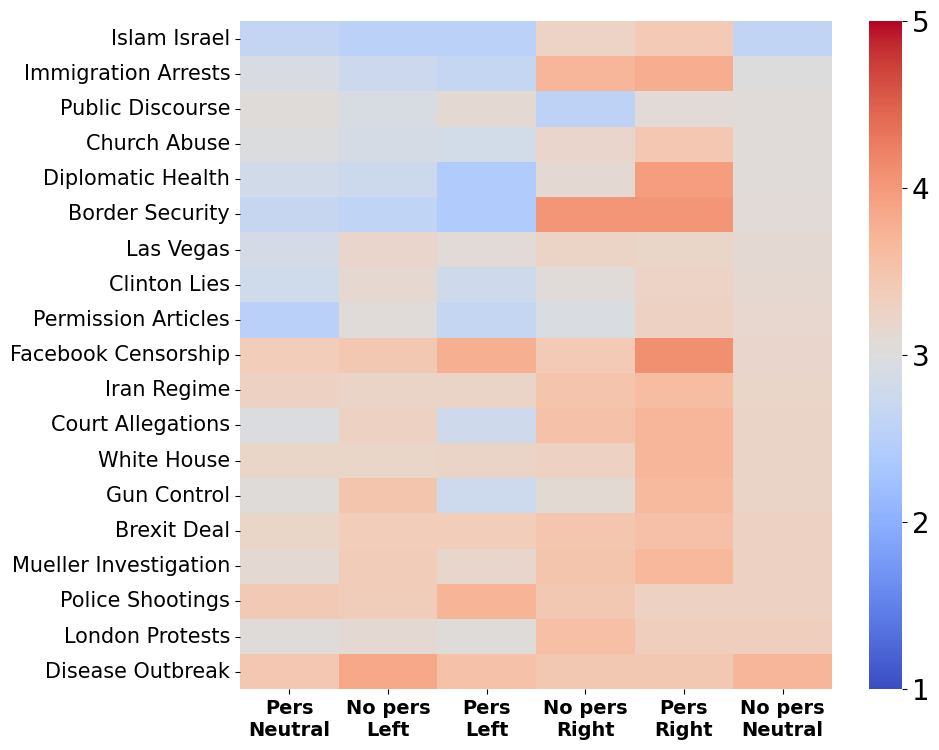

In [124]:
plot_topic_score_heatmap(
    news_effects,
    news_topic_labels_llm,
    title="News Dataset",
    output_path="../figures/news_topics_heatmap.pdf",
)

# Alternative prompt 

In [36]:
from scipy.stats import kendalltau, spearmanr
import numpy as np
import pandas as pd


NO_PROPAGANDA_LABELS = {"no_propaganda", "none"}


def normalize_columns(df):
    """
    Normalize column names across tweets/news datasets.
    """
    return df.rename(
        columns={
            "score_avg": "score",
            "label": "propaganda_category",  # present only in news
        }
    )


def add_has_propaganda(df):
    """
    Add binary propaganda flag.
    """
    df = df.copy()

    df["has_propaganda"] = (
        ~df["propaganda_category"]
        .astype(str)
        .isin(NO_PROPAGANDA_LABELS)
    ).astype(int)

    return df


def get_group_cols(df):
    """
    Use the correct text column depending on the dataset.
    """
    text_col = (
        "text_normalized"
        if "text_normalized" in df.columns
        else "text"
    )

    return [
        text_col,
        "type",
        "propaganda_category",
        "model",
    ]


def prepare_main_generations(folder, prefix, techniques, models, process=True):
    left, right, neutral = load_datasets(folder=folder, prefix=prefix)

    dfs = [
        normalize_columns(df)
        for df in [left, right, neutral]
    ]

    if process:
        dfs = [process_data(df) for df in dfs]

    data = combine_wings(dfs, include_neutral=True)
    data = add_has_propaganda(data)

    data = data[data["model"].isin(models)].copy()
    data_sel = data[data["propaganda_category"].isin(techniques)].copy()

    return data, data_sel

def prepare_alternative_generations(folder, prefix, techniques, models):
    """
    Load and prepare the alternative prompt generations.
    """
    left, right, neutral = load_datasets(
        folder=folder,
        prefix=prefix
    )

    dfs = [
        normalize_columns(df)
        for df in [left, right, neutral]
    ]

    data = combine_wings(
        dfs,
        include_neutral=True
    )

    data = add_has_propaganda(data)

    data = data[
        data["model"].isin(models)
    ].copy()

    data_sel = data[
        data["propaganda_category"].isin(techniques)
    ].copy()

    # Reverse alternative prompt scale
    data_sel["score"] = 6 - data_sel["score"]

    return data, data_sel


def compare_prompt_variants(original, alternative):
    """
    Compare original vs alternative prompting.
    """
    group_cols = get_group_cols(original)

    merged = original.merge(
        alternative,
        on=group_cols,
        suffixes=("_orig", "_alt"),
    )

    score_diff = np.abs(
        merged["score_orig"] - merged["score_alt"]
    )

    results = {
        "n_pairs": len(merged),
        "mean_absolute_difference": score_diff.mean(),
        "agreement_within_1_point": (
            score_diff <= 1
        ).mean(),
      
    }

    return merged, results


def print_comparison_results(results):
    print(f"N pairs: {results['n_pairs']:,}")
    print(
        f"Mean Absolute Difference: "
        f"{results['mean_absolute_difference']:.3f}"
    )
    print(
        f"Agreement within 1 point: "
        f"{results['agreement_within_1_point']:.3%}"
    )
  

## TWEETS

In [37]:
tweets, tweets_sel = prepare_main_generations(
    folder="./generations/merged_tweets_seed",
    prefix="tweets_seedaggregated",
    techniques=TECHNIQUES_TWEETS,
    process=True,
    models=MODELS,
)

tweets_alt, tweets_sel_alt = prepare_alternative_generations(
    folder="./generations/merged_tweets_alternative",
    prefix="tweets_alternative",
    techniques=TECHNIQUES_TWEETS,
    models=MODELS,
)

tweets_merged, tweets_results = compare_prompt_variants(
    tweets_sel,
    tweets_sel_alt,
)

print_comparison_results(tweets_results)

N pairs: 141,840
Mean Absolute Difference: 1.052
Agreement within 1 point: 70.990%


## NEWS

In [38]:
news, news_sel = prepare_main_generations(
    folder="./generations/merged_news_seed",
    prefix="news_seedaggregated",
    techniques=TECHNIQUES,
    process=False,
    models=MODELS,
)

news_alt, news_sel_alt = prepare_alternative_generations(
    folder="./generations/merged_news_alternative",
    prefix="news_alternative",
    techniques=TECHNIQUES,
    models=MODELS,
)

news_merged, news_results = compare_prompt_variants(
    news_sel,
    news_sel_alt,
)

print_comparison_results(news_results)

N pairs: 156,564
Mean Absolute Difference: 0.809
Agreement within 1 point: 80.038%
